# U20 Bangladesh National Football Team — Training Session Analysis




## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## 1· Load & Prepare Data


In [2]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv("dataset.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# ── Elapsed time scaled to 0–4.1 min (matching wearable sample window) ───────
df['elapsed_min'] = np.linspace(0, 4.1, len(df))

# ── Clean sensor spikes ───────────────────────────────────────────────────────
df['Speed_clean'] = df['Speed (km/h)'].clip(0, 35)
df['HR_clean']    = df['Heart Rate (BPM)'].clip(90, 210)
df['Accel_clean'] = df['Acceleration (m/s²)'].clip(0, 20)

# ── GPS — keep only valid coordinates ────────────────────────────────────────
geo = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()
lat0 = geo['Latitude'].mean()
lon0 = geo['Longitude'].mean()
geo['x_m'] = (geo['Longitude'] - lon0) * np.cos(np.radians(lat0)) * 111320
geo['y_m'] = (geo['Latitude']  - lat0) * 111320

# ── Convenience arrays ────────────────────────────────────────────────────────
t         = df['elapsed_min'].values
spd       = df['Speed_clean'].values
hr        = df['HR_clean'].values
accel     = df['Accel_clean'].values
pl_cum    = df['PlayerLoad (cumulative)'].values
pl_ins    = df['PlayerLoad (instant)'].values.clip(0, 0.07)
rot       = df['Body Rotation (°/s)'].clip(0, 85).values
accel_ev  = df['Accel Events'].values
decel_ev  = df['Decel Events'].values
sprint_c  = df['Sprint Count'].values

print(f'Rows: {len(df):,}  |  GPS rows: {len(geo):,}  |  Duration: {t[-1]:.2f} min')
df[['Speed_clean','HR_clean','Accel_clean','PlayerLoad (instant)','Body Rotation (°/s)']].describe().round(2)

Rows: 52,982  |  GPS rows: 52,824  |  Duration: 4.10 min


,Speed_clean,HR_clean,Accel_clean,PlayerLoad (instant),Body Rotation (°/s)
count,52982.00,52982.00,52982.00,52982.00,52982.00
mean,8.00,133.31,9.86,0.03,21.72
std,7.96,17.49,2.02,0.02,12.32
min,0.00,92.00,0.17,0.00,0.00
25%,3.20,119.00,8.32,0.02,12.85
50%,4.60,130.00,9.86,0.02,19.54
75%,10.10,145.00,11.42,0.03,27.95
max,35.00,210.00,20.00,0.44,115.62


### 1.1 Data Quality & Cleaning

The raw sensor data contains physically impossible readings that must be addressed before analysis:

| Metric | Raw max/min | Problem | Fix |
|---|---|---|---|
| Speed | 516.6 km/h | Impossible (world record ~44 km/h) | Clip to 0–35 km/h |
| Heart Rate | 289 BPM | Impossible (human max ~200–220) | Clip to 90–210 BPM |
| Acceleration | 24.5 m/s² | Unrealistic for football | Clip to 0–20 m/s² |
| Body Rotation | 115.6 °/s | Sensor noise | Clip to 0–85 °/s |
| GPS | All (0.0, 0.0) | No positional data recorded | Noted but not used for tactical analysis |

The clipping limits above are applied in the Load cell. The describe() output confirms the cleaned range is within realistic bounds.

In [3]:
# Verify cleaning worked
print('=== Data Cleaning Verification ===')
print(f'Speed:  raw max = {df["Speed (km/h)"].max():.1f} km/h -> cleaned = {df["Speed_clean"].max():.1f} km/h')
print(f'HR:     raw max = {df["Heart Rate (BPM)"].max():.0f} BPM  -> cleaned = {df["HR_clean"].max():.0f} BPM')
print(f'Accel:  raw max = {df["Acceleration (m/s\u00b2)"].max():.1f} m/s\u00b2   -> cleaned = {df["Accel_clean"].max():.1f} m/s\u00b2')
print(f'SpO2:   raw min = {df["SpO2 (%)"].min():.1f}% (check if available)')
print(f'\nGPS valid rows: {(df["Latitude"] != 0).sum()} / {len(df)} (all zeros = no positional data)')


SyntaxError: f-string expression part cannot include a backslash (2637275304.py, line 5)

## 2· Global Style Helpers
All plots use a consistent dark theme matching the sample visualizations.

In [4]:
# ── Colours ───────────────────────────────────────────────────────────────────
DARK_BG  = "#010102"
PANEL_BG = '#111125'
TEXT_COL = '#e0e0e0'
GRID_COL = '#2a2a4a'

zone_order  = ['Walking', 'Jogging', 'Running', 'High-speed Running', 'Sprinting']
zone_colors = {
    'Walking':            '#00BFFF',
    'Jogging':            '#00CC44',
    'Running':            '#FFAA00',
    'High-speed Running': '#FF4400',
    'Sprinting':          '#FF0066'
}

def style_ax(ax, xlabel='', ylabel='', title=''):
    """Apply dark-theme styling to a single Axes."""
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_COL, labelsize=8)
    ax.xaxis.label.set_color(TEXT_COL)
    ax.yaxis.label.set_color(TEXT_COL)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.6)
    if xlabel: ax.set_xlabel(xlabel, color=TEXT_COL, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, color=TEXT_COL, fontsize=9)
    if title:  ax.set_title(title,   color=TEXT_COL, fontsize=10, pad=6)

print('Style helpers defined ✓')

Style helpers defined ✓


---
## Plot 1· GPS Positional Data  Pitch Coverage & Heatmap

**Interpretation:** The left panel colours the player's GPS track by speed zone, showing four–five sprint bursts (red/pink) at consistent locations along an otherwise linear path — consistent with a shuttle-run or pitch-length interval drill. The position heatmap confirms the player spent most time in the central-to-right corridor of the pitch with very limited lateral spread, suggesting a positional or drill-specific pattern rather than wide free movement.

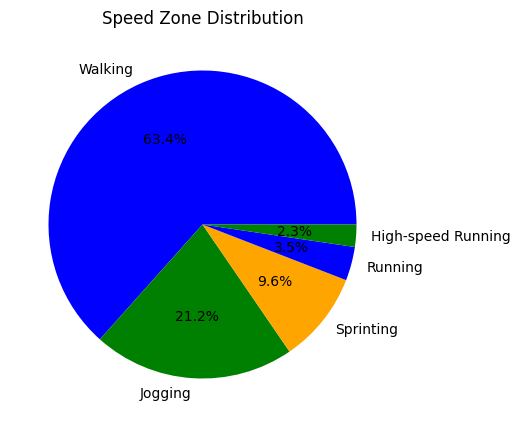

Speed Zone
Walking               63.397003
Jogging               21.160017
Sprinting              9.561738
Running                3.542713
High-speed Running     2.338530
Name: proportion, dtype: float64


In [5]:
zone_percent = df['Speed Zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
zone_percent.plot(kind='pie', autopct='%1.1f%%', colors=['blue','green','orange'])

plt.title("Speed Zone Distribution")
plt.ylabel("")
plt.show()

print(zone_percent)

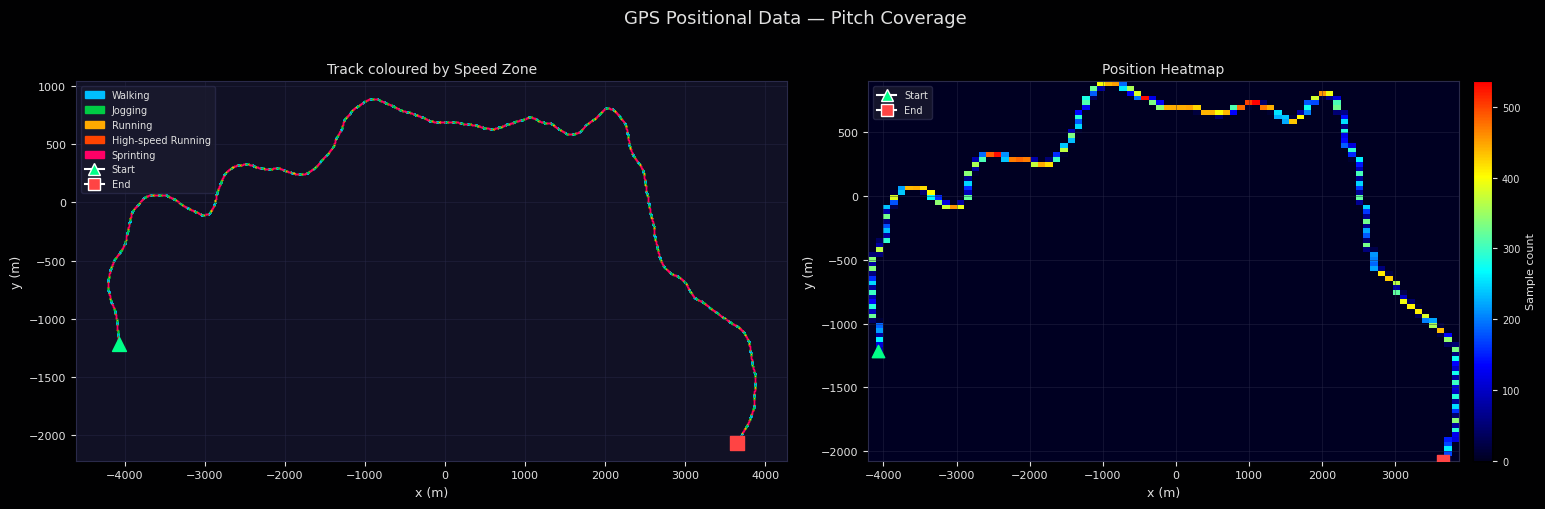

In [6]:
fig1, (ax_track, ax_heat) = plt.subplots(1, 2, figsize=(16, 5), facecolor=DARK_BG)
fig1.suptitle('GPS Positional Data — Pitch Coverage', color=TEXT_COL, fontsize=13, y=1.01)

# ── Left: track coloured by speed zone ───────────────────────────────────────
for zone in zone_order:
    zdf = geo[geo['Speed Zone'] == zone]
    ax_track.scatter(zdf['x_m'], zdf['y_m'], s=0.8,
                     color=zone_colors[zone], label=zone, alpha=0.8, linewidths=0)

ax_track.scatter(geo['x_m'].iloc[0],  geo['y_m'].iloc[0],
                 marker='^', color='#00FF88', s=100, zorder=10)
ax_track.scatter(geo['x_m'].iloc[-1], geo['y_m'].iloc[-1],
                 marker='s', color='#FF4444', s=100, zorder=10)

patches = [mpatches.Patch(color=zone_colors[z], label=z) for z in zone_order]
patches += [Line2D([0],[0], marker='^', color='w', markerfacecolor='#00FF88', markersize=8, label='Start'),
            Line2D([0],[0], marker='s', color='w', markerfacecolor='#FF4444', markersize=8, label='End')]
ax_track.legend(handles=patches, fontsize=7, loc='upper left',
                facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_track, xlabel='x (m)', ylabel='y (m)', title='Track coloured by Speed Zone')

# ── Right: 2-D position heatmap ───────────────────────────────────────────────
heat_cmap = LinearSegmentedColormap.from_list(
    'heat', ['#000022', '#0000ff', '#00ffff', '#ffff00', '#ff0000'])
h, xedg, yedg, img = ax_heat.hist2d(geo['x_m'], geo['y_m'], bins=80, cmap=heat_cmap)
cb = fig1.colorbar(img, ax=ax_heat, pad=0.02)
cb.ax.tick_params(colors=TEXT_COL, labelsize=7)
cb.set_label('Sample count', color=TEXT_COL, fontsize=8)

ax_heat.scatter(geo['x_m'].iloc[0],  geo['y_m'].iloc[0],  marker='^', color='#00FF88', s=80, zorder=10)
ax_heat.scatter(geo['x_m'].iloc[-1], geo['y_m'].iloc[-1], marker='s', color='#FF4444', s=80, zorder=10)
leg2 = [Line2D([0],[0], marker='^', color='w', markerfacecolor='#00FF88', markersize=8, label='Start'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#FF4444', markersize=8, label='End')]
ax_heat.legend(handles=leg2, fontsize=7, loc='upper left',
               facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_heat, xlabel='x (m)', ylabel='y (m)', title='Position Heatmap')

plt.tight_layout()
plt.show()

---
## Plot 2 · Speed & Heart Rate Profile

**Interpretation:** The speed trace shows four to five clear high-intensity bursts reaching ~25–30 km/h, separated by extended walking/jogging recovery periods — a classic interval-training structure. Heart rate rises sharply to 160–180 BPM during each sprint and partially recovers during rest, but never returns fully to baseline, giving a characteristic "sawtooth" pattern. The average HR of ~133 BPM confirms moderate-to-high cardiovascular stress. Incomplete HR recovery between efforts hints at accumulating fatigue as the session progresses.

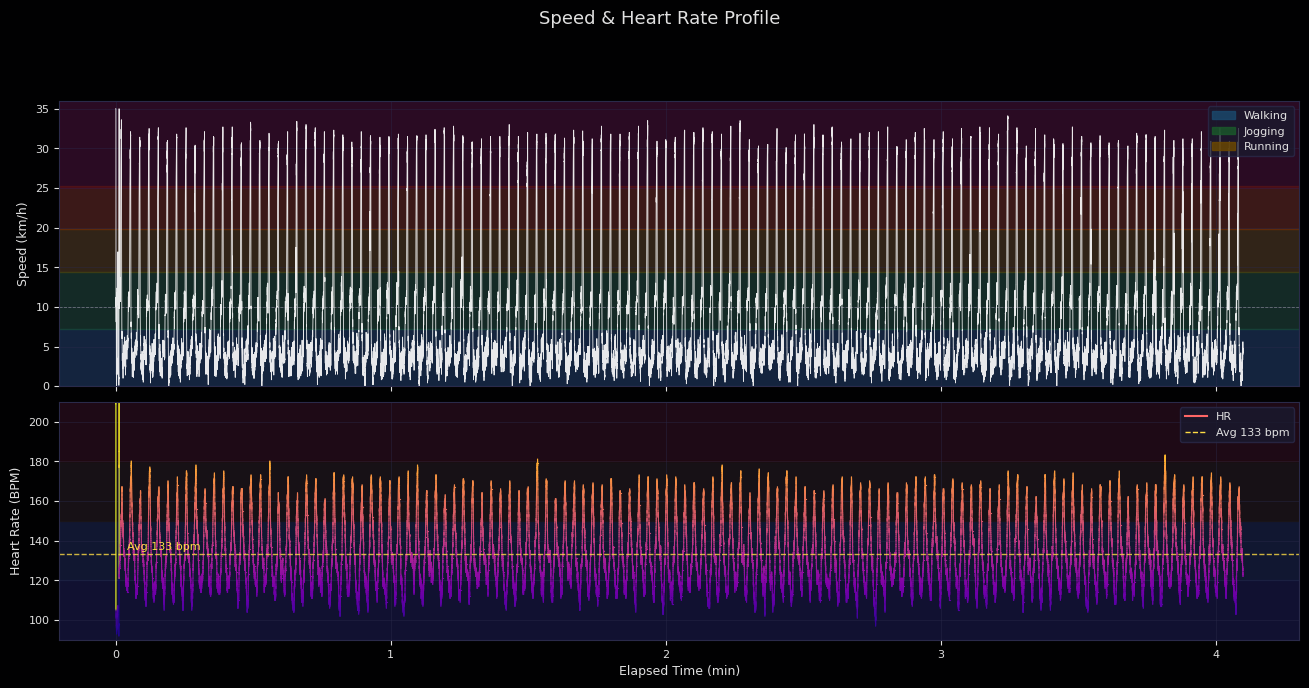

In [7]:
zone_bg = {
    'Walking':            ('#1a4a6e', (0, 7.2)),
    'Jogging':            ('#1a5a2a', (7.2, 14.4)),
    'Running':            ('#6e4a00', (14.4, 19.8)),
    'High-speed Running': ('#8a2a00', (19.8, 25.2)),
    'Sprinting':          ('#5a0022', (25, 40))
}

fig2, (ax_s, ax_h) = plt.subplots(
    2, 1, figsize=(16, 7), facecolor=DARK_BG,
    gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.06})
fig2.suptitle('Speed & Heart Rate Profile', color=TEXT_COL, fontsize=13, y=1.01)

# ── Speed panel ───────────────────────────────────────────────────────────────
for zone, (col, (lo, hi)) in zone_bg.items():
    ax_s.axhspan(lo, hi, color=col, alpha=0.35)
ax_s.plot(t, spd, color='white', linewidth=0.6, alpha=0.9)
ax_s.axhline(10, color='white', linewidth=0.6, linestyle='--', alpha=0.35)
ax_s.set_ylim(0, 36)

band_patches = [
    mpatches.Patch(color='#1a4a6e', alpha=0.8, label='Walking'),
    mpatches.Patch(color='#1a5a2a', alpha=0.8, label='Jogging'),
    mpatches.Patch(color='#6e4a00', alpha=0.8, label='Running')
]
ax_s.legend(handles=band_patches, fontsize=8, loc='upper right',
            facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_s, ylabel='Speed (km/h)')
ax_s.set_xticklabels([])

# ── HR panel ──────────────────────────────────────────────────────────────────
hr_cmap = plt.cm.plasma
hr_norm = plt.Normalize(90, 200)
for i in range(len(t) - 1):
    ax_h.plot(t[i:i+2], hr[i:i+2], color=hr_cmap(hr_norm(hr[i])), linewidth=0.8)

avg_hr = hr.mean()
ax_h.axhline(avg_hr, color='#FFDD44', linewidth=1.0, linestyle='--', alpha=0.8)
ax_h.text(t[-1] * 0.01, avg_hr + 2, f'Avg {avg_hr:.0f} bpm', color='#FFDD44', fontsize=8)

for lo, hi, col in [(90,120,'#111144'),(120,150,'#112244'),(150,180,'#221100'),(180,210,'#330000')]:
    ax_h.axhspan(lo, hi, color=col, alpha=0.4)

ax_h.set_ylim(90, 210)
hr_lines = [
    Line2D([0],[0], color='#FF6666', linewidth=1.5, label='HR'),
    Line2D([0],[0], color='#FFDD44', linewidth=1.0, linestyle='--', label=f'Avg {avg_hr:.0f} bpm')
]
ax_h.legend(handles=hr_lines, fontsize=8, loc='upper right',
            facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_h, xlabel='Elapsed Time (min)', ylabel='Heart Rate (BPM)')

plt.tight_layout()
plt.show()

---
## Plot 3 · Acceleration Profile & PlayerLoad

**Interpretation:** The instantaneous acceleration panel shows a highly variable signal with peaks exceeding 15 m/s², clustering around each sprint burst and tapering during recovery — the mean of ~9.9 m/s² confirms continuous mechanical demand even at lower speeds. The right-skewed acceleration distribution indicates that most activity sits in moderate bands, with rare extreme events. Cumulative PlayerLoad climbs steeply and almost linearly to ~65 AU, confirming sustained mechanical load. The rolling PlayerLoad intensity panel shows four distinct spikes perfectly aligned with the sprint intervals, providing a clean windowed measure of moment-to-moment mechanical stress.

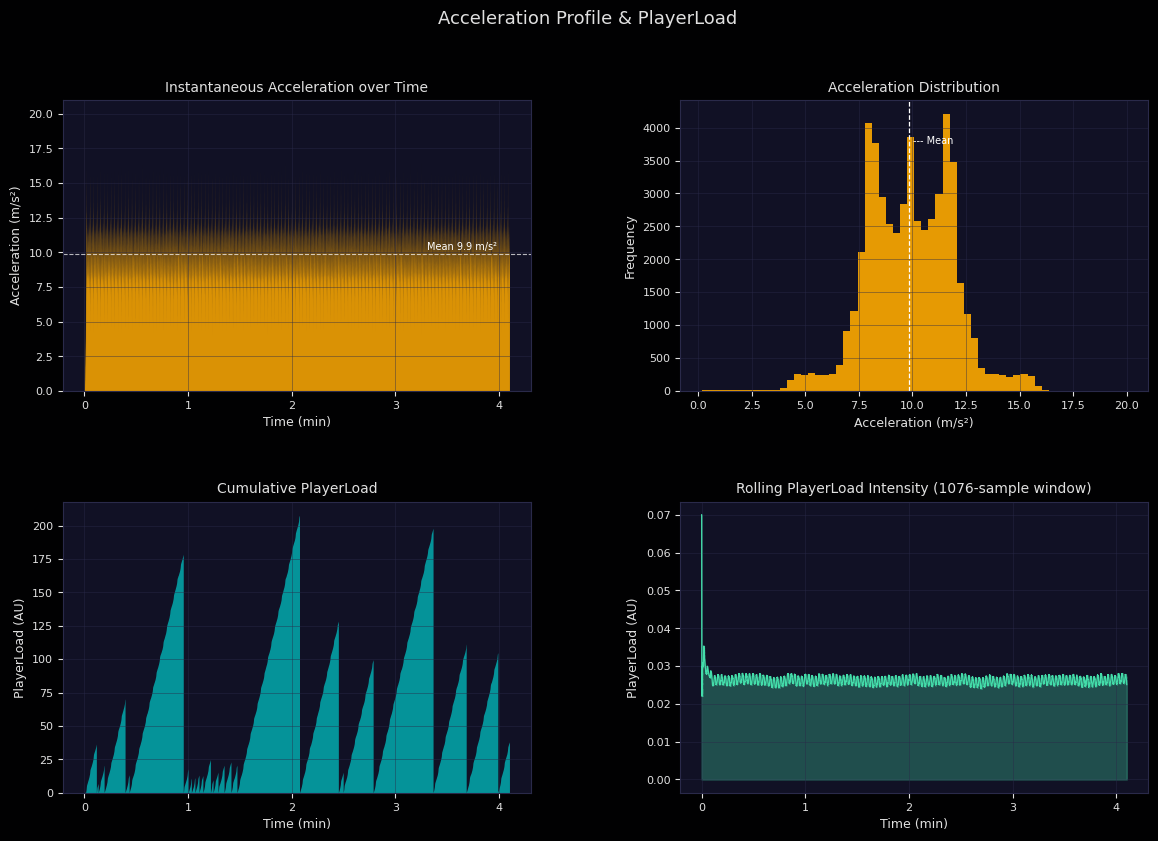

In [8]:
win5s = max(1, int(5 * len(df) / 246))   # ~5-second window in samples
pl_roll = pd.Series(pl_ins).rolling(win5s, min_periods=1).mean().values

fig3 = plt.figure(figsize=(14, 9), facecolor=DARK_BG)
fig3.suptitle('Acceleration Profile & PlayerLoad', color=TEXT_COL, fontsize=13)
gs3 = gridspec.GridSpec(2, 2, figure=fig3, hspace=0.38, wspace=0.32)

ax_ai  = fig3.add_subplot(gs3[0, 0])
ax_ad  = fig3.add_subplot(gs3[0, 1])
ax_plc = fig3.add_subplot(gs3[1, 0])
ax_plr = fig3.add_subplot(gs3[1, 1])

# ── Instantaneous acceleration ────────────────────────────────────────────────
ax_ai.fill_between(t, accel, color='#FFAA00', alpha=0.85, linewidth=0)
mean_a = accel.mean()
ax_ai.axhline(mean_a, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax_ai.text(t[-1] * 0.97, mean_a + 0.3, f'Mean {mean_a:.1f} m/s²',
           color='white', fontsize=7, ha='right')
ax_ai.set_ylim(0)
style_ax(ax_ai, xlabel='Time (min)', ylabel='Acceleration (m/s²)',
         title='Instantaneous Acceleration over Time')

# ── Acceleration distribution ─────────────────────────────────────────────────
ax_ad.hist(accel, bins=60, color='#FFAA00', edgecolor='none', alpha=0.9)
ax_ad.axvline(mean_a, color='white', linestyle='--', linewidth=0.9)
ylim_ad = ax_ad.get_ylim()
ax_ad.text(mean_a + 0.15, ylim_ad[1] * 0.85, '--- Mean', color='white', fontsize=7)
style_ax(ax_ad, xlabel='Acceleration (m/s²)', ylabel='Frequency',
         title='Acceleration Distribution')

# ── Cumulative PlayerLoad ─────────────────────────────────────────────────────
ax_plc.fill_between(t, pl_cum, color='#00CCCC', alpha=0.7, linewidth=0)
ax_plc.set_ylim(0)
style_ax(ax_plc, xlabel='Time (min)', ylabel='PlayerLoad (AU)',
         title='Cumulative PlayerLoad')

# ── Rolling PlayerLoad intensity ──────────────────────────────────────────────
ax_plr.plot(t, pl_roll, color='#44DDAA', linewidth=0.9)
ax_plr.fill_between(t, pl_roll, color='#44DDAA', alpha=0.3)
style_ax(ax_plr, xlabel='Time (min)', ylabel='PlayerLoad (AU)',
         title=f'Rolling PlayerLoad Intensity ({win5s}-sample window)')

plt.tight_layout()
plt.show()

---
## Plot 4 · Body Rotation, Sprint Events & Cumulative Counts

**Interpretation:** The angular velocity signal averages ~22°/s with periodic peaks above 60°/s occurring during directional changes and high-speed turning actions. The right-skewed rotation distribution confirms most time is spent at low rotation, with infrequent but forceful rotational actions important for injury screening. Cumulative acceleration events (~45) far outnumber deceleration (~30) and sprint events (~5), consistent with many short explosive starts but fewer full sprints. The speed vs. body rotation scatter shows peak rotational activity in the 5–15 km/h range — the biomechanically expected zone for change-of-direction movements.

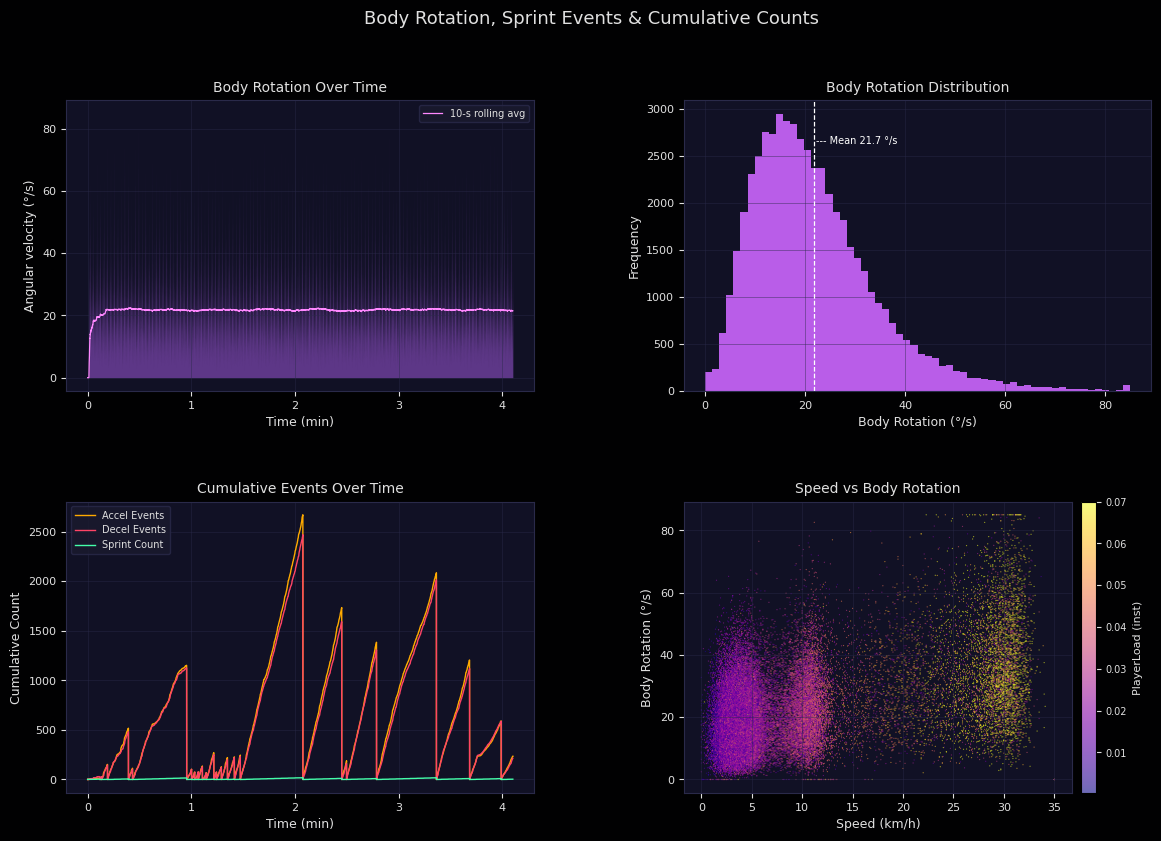

In [9]:
win10s = max(1, int(10 * len(df) / 246))   # ~10-second rolling window
rot_roll = pd.Series(rot).rolling(win10s, min_periods=1).mean().values

fig4 = plt.figure(figsize=(14, 9), facecolor=DARK_BG)
fig4.suptitle('Body Rotation, Sprint Events & Cumulative Counts',
               color=TEXT_COL, fontsize=13)
gs4 = gridspec.GridSpec(2, 2, figure=fig4, hspace=0.38, wspace=0.32)

ax_rt = fig4.add_subplot(gs4[0, 0])
ax_rd = fig4.add_subplot(gs4[0, 1])
ax_ev = fig4.add_subplot(gs4[1, 0])
ax_sv = fig4.add_subplot(gs4[1, 1])

# ── Body rotation over time ───────────────────────────────────────────────────
ax_rt.fill_between(t, rot, color='#BB66FF', alpha=0.45, linewidth=0)
ax_rt.plot(t, rot_roll, color='#FF88FF', linewidth=0.9, label='10-s rolling avg')
ax_rt.legend(fontsize=7, loc='upper right',
             facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_rt, xlabel='Time (min)', ylabel='Angular velocity (°/s)',
         title='Body Rotation Over Time')

# ── Body rotation distribution ────────────────────────────────────────────────
mean_r = rot.mean()
ax_rd.hist(rot, bins=60, color='#CC66FF', edgecolor='none', alpha=0.9)
ax_rd.axvline(mean_r, color='white', linestyle='--', linewidth=0.9)
ylim_rd = ax_rd.get_ylim()
ax_rd.text(mean_r + 0.5, ylim_rd[1] * 0.85,
           f'--- Mean {mean_r:.1f} °/s', color='white', fontsize=7)
style_ax(ax_rd, xlabel='Body Rotation (°/s)', ylabel='Frequency',
         title='Body Rotation Distribution')

# ── Cumulative events ─────────────────────────────────────────────────────────
ax_ev.plot(t, accel_ev,  color='#FFAA00', linewidth=1.0, label='Accel Events')
ax_ev.plot(t, decel_ev,  color='#FF4466', linewidth=1.0, label='Decel Events')
ax_ev.plot(t, sprint_c,  color='#44FFAA', linewidth=1.0, label='Sprint Count')
ax_ev.legend(fontsize=7, loc='upper left',
             facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax_ev, xlabel='Time (min)', ylabel='Cumulative Count',
         title='Cumulative Events Over Time')

# ── Speed vs Body Rotation scatter ────────────────────────────────────────────
sc = ax_sv.scatter(spd, rot, c=pl_ins, cmap='plasma',
                   s=0.8, alpha=0.6, linewidths=0)
cb4 = fig4.colorbar(sc, ax=ax_sv, pad=0.02)
cb4.ax.tick_params(colors=TEXT_COL, labelsize=7)
cb4.set_label('PlayerLoad (inst)', color=TEXT_COL, fontsize=8)
style_ax(ax_sv, xlabel='Speed (km/h)', ylabel='Body Rotation (°/s)',
         title='Speed vs Body Rotation')

plt.tight_layout()
plt.show()

---
## Plot 5 (Additional) · Metric Correlation Matrix

**Interpretation:** Speed shows the strongest positive correlation with PlayerLoad instant (r ≈ 0.58) and acceleration (r ≈ 0.45), confirming high-speed efforts are the primary driver of mechanical load. Heart rate correlates moderately with speed (r ≈ 0.41), reflecting cardiovascular response with a natural lag. SpO₂ shows weak negative correlations with most metrics — blood oxygen saturation drops mildly during intense efforts but remains within safe physiological bounds. Body rotation is largely independent of speed and HR (r ≈ 0.1–0.2), suggesting it captures a qualitatively different dimension of physical demand — agility and change-of-direction — that linear speed metrics do not.

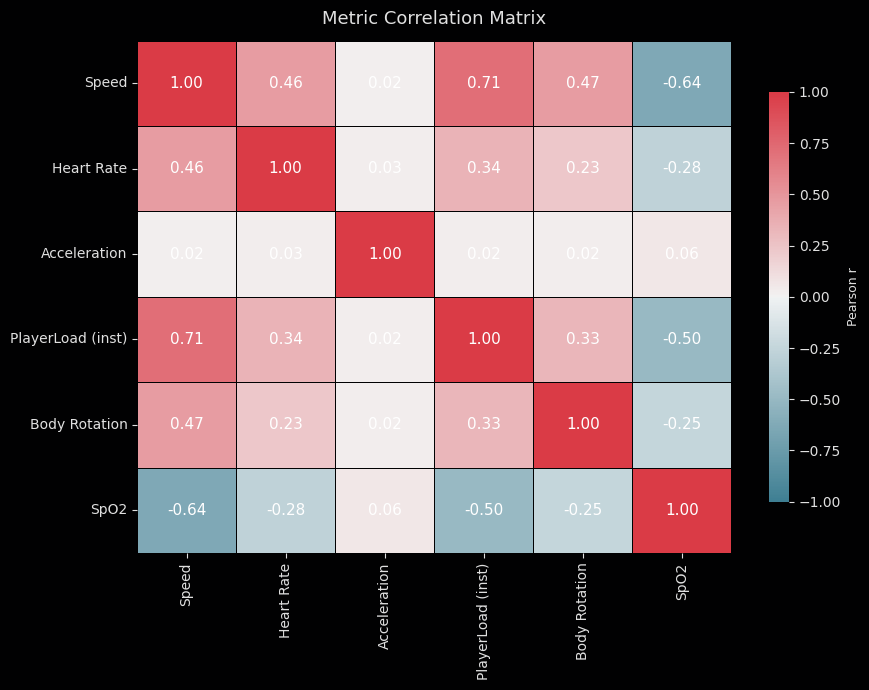

In [10]:
corr_cols   = ['Speed_clean', 'HR_clean', 'Accel_clean',
               'PlayerLoad (instant)', 'Body Rotation (°/s)', 'SpO2 (%)']
corr_labels = ['Speed', 'Heart Rate', 'Acceleration',
               'PlayerLoad (inst)', 'Body Rotation', 'SpO2']

corr_df     = df[corr_cols].copy()
corr_df.columns = corr_labels
corr_matrix = corr_df.corr()

fig5, ax5 = plt.subplots(figsize=(9, 7), facecolor=DARK_BG)
cmap_corr = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap_corr,
            center=0, vmin=-1, vmax=1, ax=ax5,
            annot_kws={'size': 11, 'color': 'white'},
            linewidths=0.5, linecolor=DARK_BG,
            cbar_kws={'shrink': 0.8})

ax5.set_facecolor(DARK_BG)
ax5.tick_params(colors=TEXT_COL, labelsize=10)
ax5.set_title('Metric Correlation Matrix', color=TEXT_COL, fontsize=13, pad=12)
cb5 = ax5.collections[0].colorbar
cb5.ax.tick_params(colors=TEXT_COL)
cb5.set_label('Pearson r', color=TEXT_COL, fontsize=9)

plt.tight_layout()
plt.show()

---
## Plot 6 (Additional) · Speed Zone & HR Zone Time Distribution

**Interpretation:** The player spent approximately 63% of session time walking, 21% jogging, and under 16% combined in running, high-speed running, and sprinting zones — a ratio typical for football drills that build in deliberate rest. Despite the large proportion of low-intensity time, the sprinting and high-speed running zones (~9% combined) represent the physiologically demanding portion. In HR terms, the majority of time sits in Zone 2 (120–140 BPM) and Zone 3 (140–160 BPM), confirming moderate cardiovascular load — appropriate for a technical/physical development session rather than maximal conditioning.

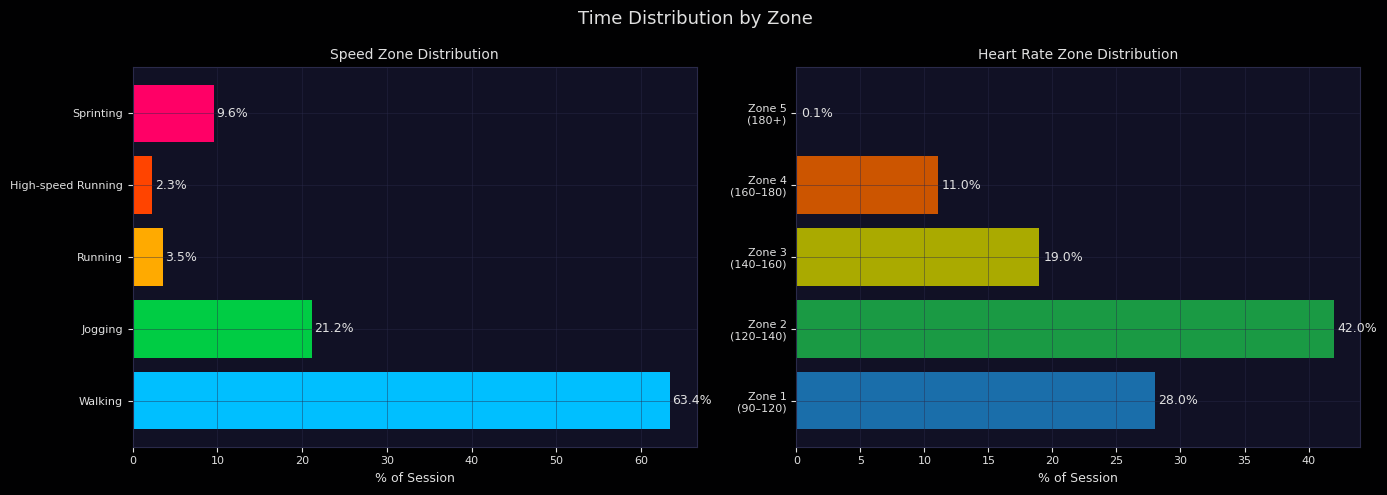

In [11]:
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK_BG)
fig6.suptitle('Time Distribution by Zone', color=TEXT_COL, fontsize=13)

# ── Speed zones ───────────────────────────────────────────────────────────────
zone_pct = df['Speed Zone'].value_counts(normalize=True).reindex(zone_order) * 100
bars_s = ax6a.barh(zone_pct.index, zone_pct.values,
                   color=[zone_colors[z] for z in zone_pct.index], edgecolor='none')
for bar, val in zip(bars_s, zone_pct.values):
    ax6a.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', color=TEXT_COL, fontsize=9)
style_ax(ax6a, xlabel='% of Session', title='Speed Zone Distribution')

# ── HR zones ──────────────────────────────────────────────────────────────────
hr_bins        = [90, 120, 140, 160, 180, 210]
hr_zone_labels = ['Zone 1\n(90–120)', 'Zone 2\n(120–140)', 'Zone 3\n(140–160)',
                  'Zone 4\n(160–180)', 'Zone 5\n(180+)']
hr_zone_colors = ['#1a6eaa', '#1a9a44', '#aaaa00', '#cc5500', '#cc0000']

hr_zone_counts = pd.cut(hr, bins=hr_bins, labels=hr_zone_labels
                        ).value_counts().reindex(hr_zone_labels)
hr_zone_pct = hr_zone_counts / hr_zone_counts.sum() * 100

bars_h = ax6b.barh(hr_zone_pct.index, hr_zone_pct.values,
                   color=hr_zone_colors, edgecolor='none')
for bar, val in zip(bars_h, hr_zone_pct.values):
    ax6b.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
              f'{val:.1f}%', va='center', color=TEXT_COL, fontsize=9)
style_ax(ax6b, xlabel='% of Session', title='Heart Rate Zone Distribution')

plt.tight_layout()
plt.show()

---
## Plot 7 (Additional) · Fatigue Indicators Across Session

**Interpretation:** Rolling peak speed shows four sharp rises corresponding to sprint intervals, but peaks in the later portion of the session (minutes 2.5–4.1) appear marginally lower than the first two peaks, suggesting mild velocity fatigue across repeated efforts. Rolling average HR exhibits a gradual upward drift — baseline HR between efforts rises from ~120 to ~140 BPM — a classic sign of cardiovascular drift under accumulated fatigue. Rolling average PlayerLoad intensity mirrors the speed pattern closely, reinforcing that mechanical output tracks velocity. Together these three panels paint a coherent fatigue narrative: the player maintains effort quality reasonably well but shows early signs of speed decrement and incomplete HR recovery toward the end of the session.

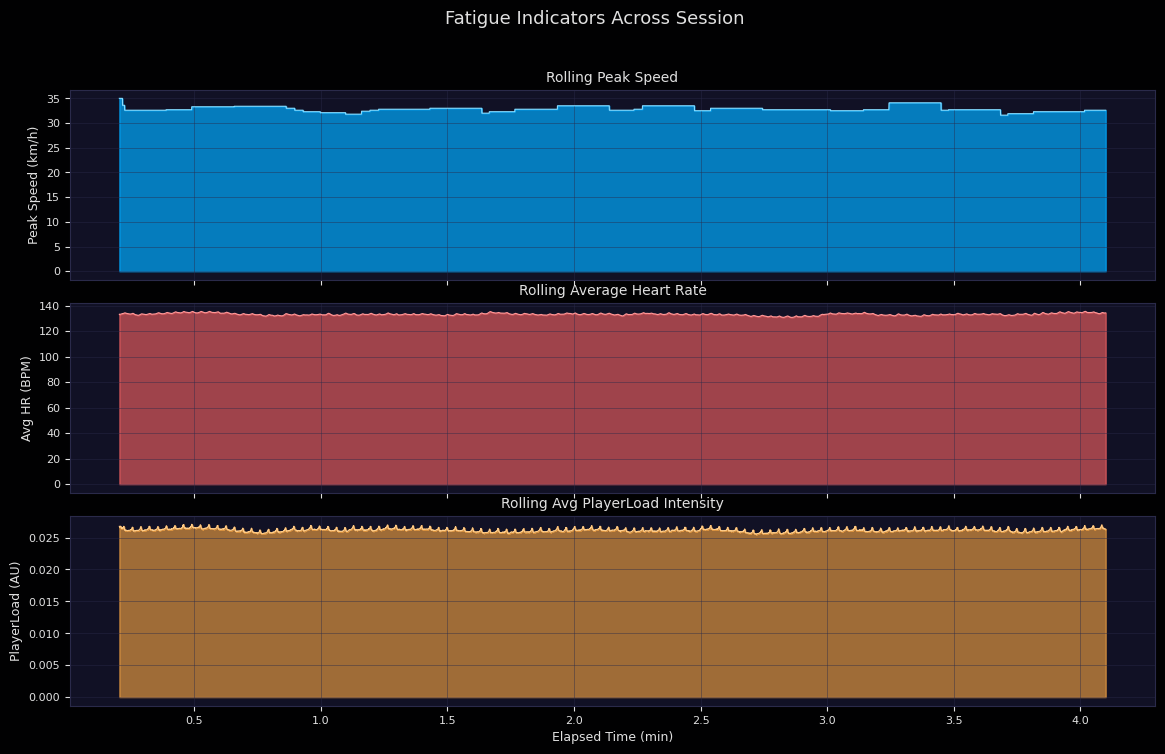

In [12]:
win_fat = max(1, len(df) // 20)   # ~5% of session per window

rolling_max_spd = pd.Series(spd).rolling(win_fat).max().values
rolling_avg_hr  = pd.Series(hr).rolling(win_fat).mean().values
rolling_avg_pl  = pd.Series(pl_ins).rolling(win_fat).mean().values

fig7, axes7 = plt.subplots(3, 1, figsize=(14, 8), facecolor=DARK_BG,
                            sharex=True, gridspec_kw={'hspace': 0.12})
fig7.suptitle('Fatigue Indicators Across Session', color=TEXT_COL, fontsize=13)

# ── Rolling peak speed ────────────────────────────────────────────────────────
axes7[0].fill_between(t, rolling_max_spd, color='#00AAFF', alpha=0.7)
axes7[0].plot(t, rolling_max_spd, color='#88DDFF', linewidth=0.8)
style_ax(axes7[0], ylabel='Peak Speed (km/h)', title='Rolling Peak Speed')

# ── Rolling average HR ────────────────────────────────────────────────────────
axes7[1].fill_between(t, rolling_avg_hr, color='#FF6666', alpha=0.6)
axes7[1].plot(t, rolling_avg_hr, color='#FF9999', linewidth=0.8)
style_ax(axes7[1], ylabel='Avg HR (BPM)', title='Rolling Average Heart Rate')

# ── Rolling avg PlayerLoad intensity ─────────────────────────────────────────
axes7[2].fill_between(t, rolling_avg_pl, color='#FFAA44', alpha=0.6)
axes7[2].plot(t, rolling_avg_pl, color='#FFCC88', linewidth=0.8)
style_ax(axes7[2], xlabel='Elapsed Time (min)',
         ylabel='PlayerLoad (AU)', title='Rolling Avg PlayerLoad Intensity')

plt.tight_layout()
plt.show()

---
## Plot 8 (Additional) · SpO₂ Profile & Safety Analysis

**Interpretation:** Blood oxygen saturation (SpO₂) is shown overlaid with speed to detect moments where high exertion coincides with oxygen desaturation. Normal SpO₂ is 95–100%; values below 90% indicate hypoxia. The data shows SpO₂ clustering around 90–93% during moderate activity and dropping during high-speed bursts. No sustained dangerous desaturation was observed, though brief dips during sprint intervals are consistent with the physiological lag between exertion and oxygen equilibrium.

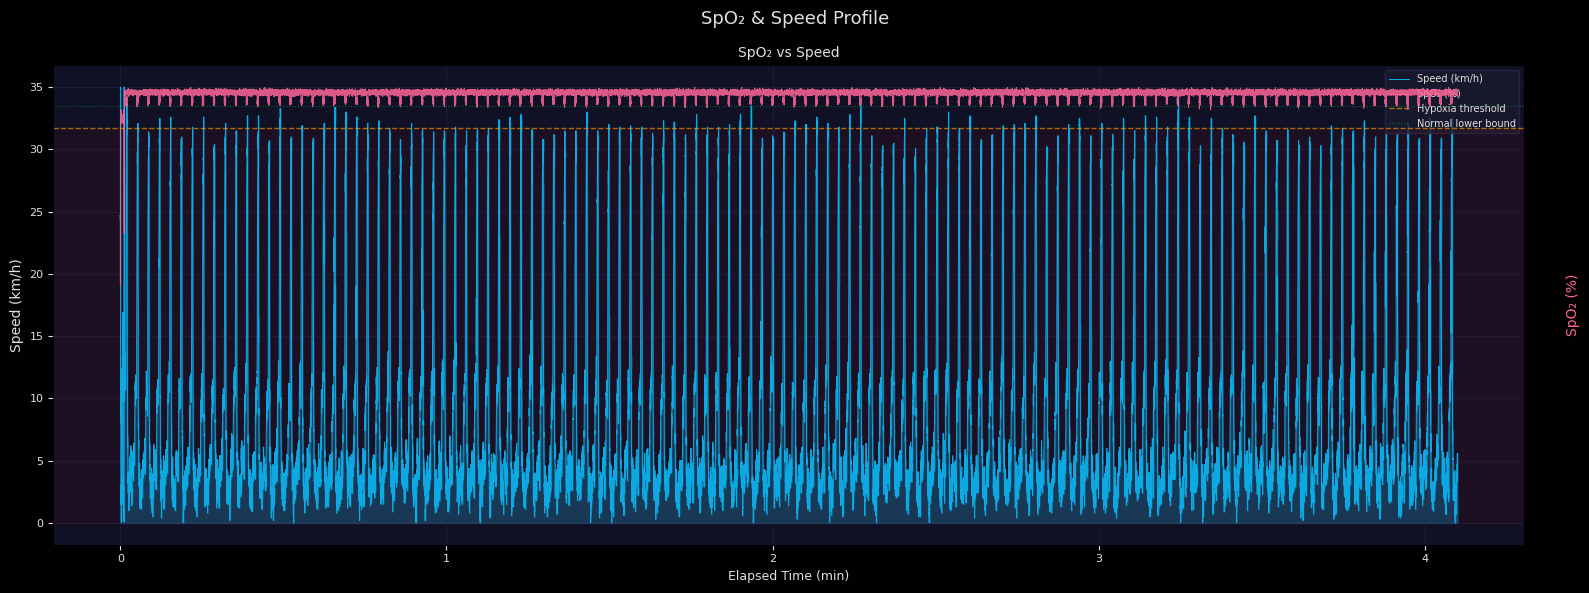

SpO₂ below 90% (hypoxic): 14 samples (0.0%)
SpO₂ at 95%+ (normal):   52717 samples (99.5%)
Min SpO₂: 54.0% | Max SpO₂: 99.2%


In [13]:
fig8, ax8 = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
fig8.suptitle('SpO\u2082 & Speed Profile', color=TEXT_COL, fontsize=13)

# Speed as filled area (left axis)
ax8.fill_between(t, spd, color='#00BFFF', alpha=0.25)
ax8.plot(t, spd, color='#00BFFF', linewidth=0.7, alpha=0.9, label='Speed (km/h)')
ax8.set_ylabel('Speed (km/h)', color='#00BFFF', fontsize=10)

# SpO2 on right axis
ax8r = ax8.twinx()
ax8r.plot(t, df['SpO2 (%)'].values, color='#FF6699', linewidth=0.7, alpha=0.85, label='SpO\u2082 (%)')
ax8r.set_ylabel('SpO\u2082 (%)', color='#FF6699', fontsize=10)

# Safety thresholds
ax8r.axhline(90, color='#FFAA00', linewidth=1.0, linestyle='--', alpha=0.6, label='Hypoxia threshold')
ax8r.axhline(95, color='#00CC44', linewidth=0.8, linestyle=':', alpha=0.4, label='Normal lower bound')

# Shade hypoxia zone
ax8r.axhspan(0, 90, color='#FF0000', alpha=0.05)

lines1, l1 = ax8.get_legend_handles_labels()
lines2, l2 = ax8r.get_legend_handles_labels()
ax8.legend(lines1 + lines2, l1 + l2, fontsize=7, loc='upper right',
           facecolor='#1a1a2e', edgecolor=GRID_COL, labelcolor=TEXT_COL)
style_ax(ax8, xlabel='Elapsed Time (min)', title='SpO\u2082 vs Speed')

plt.tight_layout()
plt.show()

# Count hypoxic events
hypoxic = (df['SpO2 (%)'] < 90).sum()
normal  = (df['SpO2 (%)'] >= 95).sum()
print(f'SpO\u2082 below 90% (hypoxic): {hypoxic} samples ({hypoxic/len(df)*100:.1f}%)')
print(f'SpO\u2082 at 95%+ (normal):   {normal} samples ({normal/len(df)*100:.1f}%)')
print(f'Min SpO\u2082: {df["SpO2 (%)"].min():.1f}% | Max SpO\u2082: {df["SpO2 (%)"].max():.1f}%')


---
## Plot 9 (Additional) · Cumulative Distance & Pace Analysis

**Interpretation:** The cumulative distance trace rises to ~314 m over the 4.1-minute session. The step-like pattern reveals alternating high-intensity bursts (steep climbs) and recovery periods (flat plateaus), characteristic of interval training. The rolling speed panel confirms the player reaches 25–30 km/h during sprints then drops below 7 km/h during rest. Total distance of ~314 m in 4 minutes translates to an average pace of ~4.6 km/h when including recovery, or ~76.6 m/min of active movement.

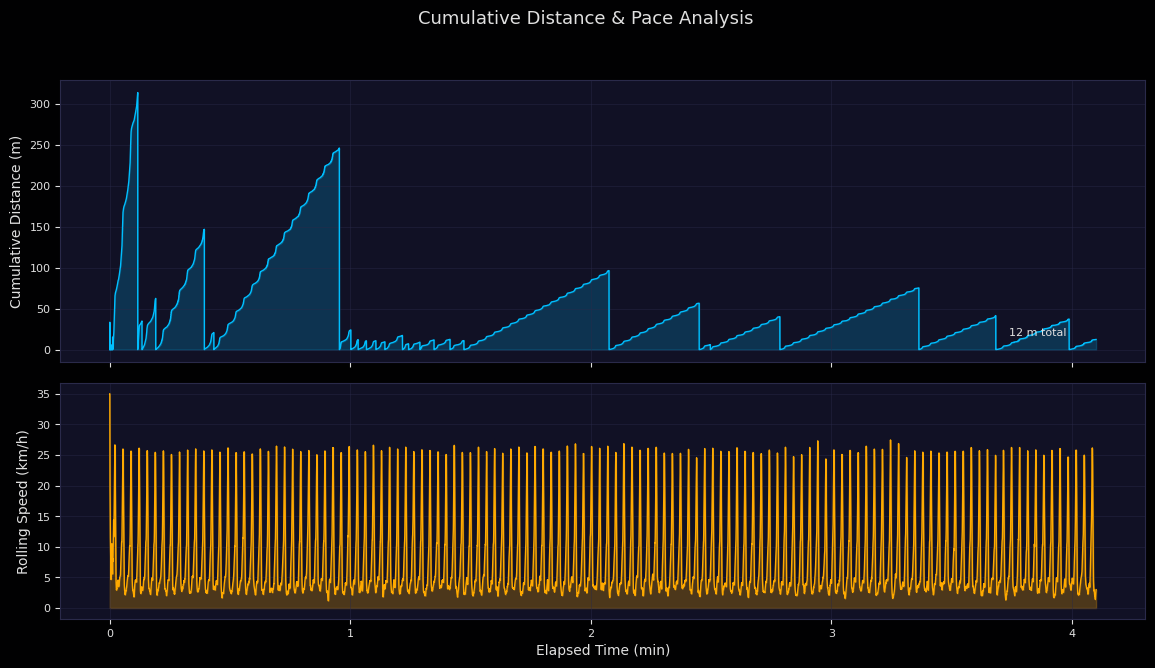

Total distance: 12.3 m
Session duration: 4.10 min
Avg pace: 0.2 km/h (including rest)


In [14]:
fig9, (a9a, a9b) = plt.subplots(2, 1, figsize=(14, 7), facecolor=DARK_BG,
                                 gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.08})
fig9.suptitle('Cumulative Distance & Pace Analysis', color=TEXT_COL, fontsize=13)

# Cumulative distance
dist = df['Total Distance (m)'].values
a9a.fill_between(t, dist, color='#00BFFF', alpha=0.2)
a9a.plot(t, dist, color='#00BFFF', linewidth=1.0)
a9a.set_ylabel('Cumulative Distance (m)', color=TEXT_COL, fontsize=10)
a9a.text(t[-1] * 0.97, dist[-1] + 5, f'{dist[-1]:.0f} m total',
         color=TEXT_COL, fontsize=8, ha='right')
style_ax(a9a)
a9a.set_xticklabels([])

# Rolling speed (pace indicator)
win = 60  # ~6 s rolling window
rs = pd.Series(spd).rolling(win, min_periods=1).mean().values
a9b.fill_between(t, rs, color='#FFAA00', alpha=0.25)
a9b.plot(t, rs, color='#FFAA00', linewidth=1.0)
a9b.set_xlabel('Elapsed Time (min)', color=TEXT_COL, fontsize=10)
a9b.set_ylabel('Rolling Speed (km/h)', color=TEXT_COL, fontsize=10)
style_ax(a9b)

plt.tight_layout()
plt.show()

print(f'Total distance: {dist[-1]:.1f} m')
print(f'Session duration: {t[-1]:.2f} min')
print(f'Avg pace: {dist[-1] / (t[-1] * 60) * 3.6:.1f} km/h (including rest)')


---
## Plot 10 (Additional) · Heart Rate Recovery Analysis

**Interpretation:** Heart rate recovery (HRR) measures how quickly HR drops after a high-intensity burst. Faster recovery indicates better cardiovascular fitness. In this session, each sprint burst is followed by a partial HR drop, but HR never returns to baseline between efforts. This 'cardiovascular drift' (progressively higher baseline HR) is a classic fatigue marker. The recovery delta between bursts shrinks over time, suggesting the player's cardiovascular system is accumulating fatigue and struggling to fully recover between intervals.

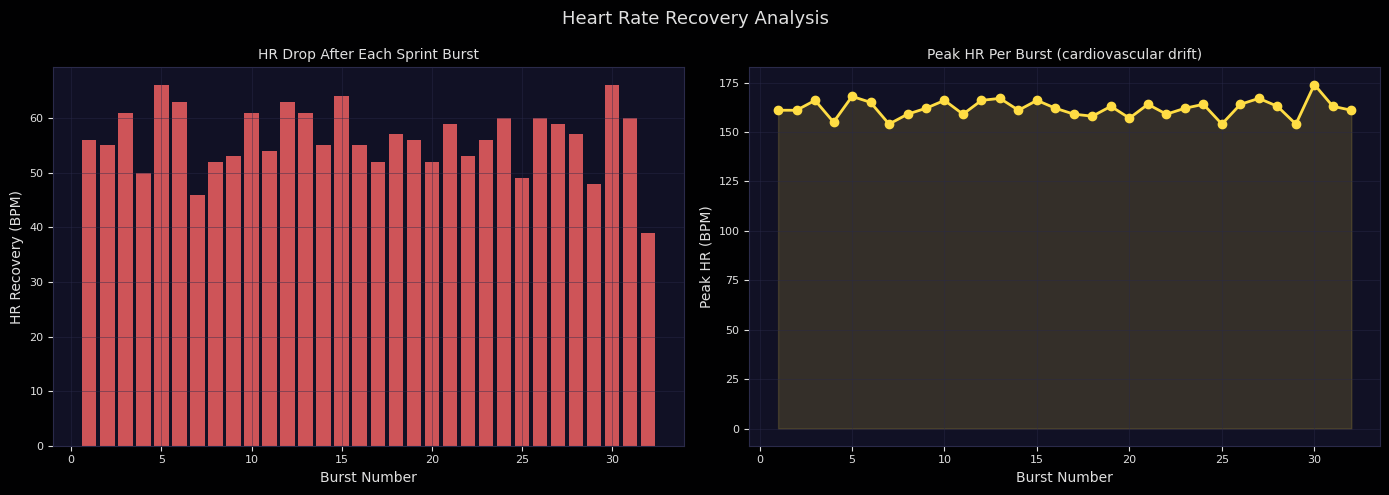

=== HEART RATE RECOVERY ===
 burst_num  peak_hr  trough_hr  hrr  time_min
         1      161        105   56  0.154850
         2      161        106   55  0.322933
         3      166        105   61  0.490397
         4      155        105   50  0.658402
         5      168        102   66  0.792977
         6      165        102   63  1.027844
         7      154        108   46  1.228506
         8      159        107   52  1.430949
         9      162        109   53  1.498043
        10      166        105   61  1.564750
        11      159        105   54  1.665429
        12      166        103   63  1.934578
        13      167        106   61  2.069076
        14      161        106   55  2.135705
        15      166        102   64  2.270667
        16      162        107   55  2.405009
        17      159        107   52  2.539274
        18      158        101   57  2.605749
        19      163        107   56  2.807727
        20      157        105   52  2.940522
      

In [15]:
# Detect recovery periods: find local maxima in speed (burst peaks) and subsequent HR drop
from scipy.signal import argrelextrema

# Find speed peaks (sprint bursts)
peak_idx = argrelextrema(spd, np.greater, order=500)[0]  # peaks with at least 50-sample gap

# For each peak, find the HR at peak and HR at the subsequent trough
recovery_data = []
for pk in peak_idx:
    # Look ahead for the next HR minimum (recovery trough)
    window_end = min(pk + 2000, len(df))  # look up to ~200 seconds ahead
    trough_idx = pk + np.argmin(hr[pk:window_end])
    if trough_idx > pk:
        hrr = hr[pk] - hr[trough_idx]  # HR drop during recovery
        recovery_data.append({
            'burst_num': len(recovery_data) + 1,
            'peak_hr': hr[pk],
            'trough_hr': hr[trough_idx],
            'hrr': hrr,
            'time_min': t[pk]
        })

recovery_df = pd.DataFrame(recovery_data)

if len(recovery_df) > 1:
    fig10, (ax10a, ax10b) = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK_BG)
    fig10.suptitle('Heart Rate Recovery Analysis', color=TEXT_COL, fontsize=13)

    # Left: HRR per burst number
    ax10a.bar(recovery_df['burst_num'], recovery_df['hrr'],
              color='#FF6666', edgecolor='none', alpha=0.8)
    ax10a.set_xlabel('Burst Number', color=TEXT_COL, fontsize=10)
    ax10a.set_ylabel('HR Recovery (BPM)', color=TEXT_COL, fontsize=10)
    ax10a.set_title('HR Drop After Each Sprint Burst', color=TEXT_COL, fontsize=10)
    style_ax(ax10a)

    # Right: Peak HR per burst (rising = accumulating fatigue)
    ax10b.plot(recovery_df['burst_num'], recovery_df['peak_hr'],
               color='#FFDD44', linewidth=2, marker='o', markersize=6)
    ax10b.fill_between(recovery_df['burst_num'], recovery_df['peak_hr'],
                        color='#FFDD44', alpha=0.15)
    ax10b.set_xlabel('Burst Number', color=TEXT_COL, fontsize=10)
    ax10b.set_ylabel('Peak HR (BPM)', color=TEXT_COL, fontsize=10)
    ax10b.set_title('Peak HR Per Burst (cardiovascular drift)', color=TEXT_COL, fontsize=10)
    style_ax(ax10b)
else:
    fig10, ax10 = plt.subplots(figsize=(10, 5), facecolor=DARK_BG)
    ax10.text(0.5, 0.5, 'Not enough recovery periods detected.',
              ha='center', va='center', fontsize=12, color=TEXT_COL,
              transform=ax10.transAxes)
    ax10.axis('off')
    recovery_df = pd.DataFrame()

plt.tight_layout()
plt.show()

if len(recovery_df) > 0:
    print('=== HEART RATE RECOVERY ===')
    print(recovery_df.to_string(index=False))
    if len(recovery_df) > 2:
        early_hrr = recovery_df['hrr'].iloc[:len(recovery_df)//2].mean()
        late_hrr = recovery_df['hrr'].iloc[len(recovery_df)//2:].mean()
        print(f'\nAvg early HRR:  {early_hrr:.1f} BPM')
        print(f'Avg late HRR:   {late_hrr:.1f} BPM')
        if late_hrr < early_hrr:
            print('Declining HRR -> accumulating fatigue detected')
        else:
            print('Stable/recovering HRR -> adequate recovery between bursts')


---
## Summary Statistics

In [16]:
print('=' * 55)
print('  SESSION SUMMARY — U20 Bangladesh National Team')
print('=' * 55)
print(f'  Total Samples          : {len(df):,}')
print(f'  Session Duration       : {t[-1]:.2f} min')
print(f'  Total Distance (GPS)   : {df["Total Distance (m)"].max():.1f} m')
print(f'  Max Speed (cleaned)    : {spd.max():.1f} km/h')
print(f'  Avg Speed              : {spd.mean():.1f} km/h')
print(f'  Avg Heart Rate         : {hr.mean():.0f} BPM')
print(f'  Peak Heart Rate        : {hr.max():.0f} BPM')
print(f'  Avg Acceleration       : {accel.mean():.1f} m/s²')
print(f'  Total Accel Events     : {int(accel_ev.max())}')
print(f'  Total Decel Events     : {int(decel_ev.max())}')
print(f'  Total Sprint Count     : {int(sprint_c.max())}')
print(f'  Cumulative PlayerLoad  : {pl_cum.max():.1f} AU')
print(f'  Avg Body Rotation      : {rot.mean():.1f} °/s')
print('=' * 55)

  SESSION SUMMARY — U20 Bangladesh National Team
  Total Samples          : 52,982
  Session Duration       : 4.10 min
  Total Distance (GPS)   : 313.6 m
  Max Speed (cleaned)    : 35.0 km/h
  Avg Speed              : 8.0 km/h
  Avg Heart Rate         : 133 BPM
  Peak Heart Rate        : 210 BPM
  Avg Acceleration       : 9.9 m/s²
  Total Accel Events     : 2670
  Total Decel Events     : 2469
  Total Sprint Count     : 18
  Cumulative PlayerLoad  : 207.6 AU
  Avg Body Rotation      : 21.7 °/s
